# CH 6 - Factor 2 - Number of Observations Used to Compute the Performance Statistic

## Objectif du notebook

Ce notebook transforme le concept EBTA du **facteur 2 du biais de minage** en intuition, simulation et code Python.

L’idée centrale est simple :

> Plus le nombre d’observations augmente, plus la performance moyenne observée devient difficile à gonfler par hasard.

En trading, cela signifie qu’un **backtest court** est fragile, même s’il semble spectaculaire.

Un **backtest long**, lui, force progressivement la stratégie à révéler son mérite réel.


## 1. Le problème étudié

Dans le cadre EBTA, le **biais de minage de données** apparaît quand on teste plusieurs règles, paramètres ou variantes, puis qu’on sélectionne celle qui affiche la meilleure performance historique.

Même si toutes les règles sont en réalité sans edge, l’une d’elles peut paraître excellente par hasard.

Ce biais dépend de plusieurs facteurs, mais Aronson insiste sur un facteur majeur :

> La taille de l’échantillon est probablement le facteur le plus important pour réduire le biais.

Pourquoi ?

Parce que la moyenne d’un petit échantillon est très instable.

Quelques observations chanceuses peuvent suffire à créer une illusion de performance.


## 2. Intuition statistique

Supposons une règle de trading qui n’a aucun véritable avantage.

Son rendement moyen réel est donc :

$$
\mu = 0
$$

Mais sur un backtest fini, la moyenne observée peut être positive ou négative :

$$
\bar{R}_n = \mu + \text{bruit d'échantillonnage}
$$

L’erreur standard de la moyenne est :

$$
SE = \frac{\sigma}{\sqrt{n}}
$$

où :

| Symbole | Signification |
|---|---|
| $\sigma$ | volatilité des rendements |
| $n$ | nombre d’observations |
| $SE$ | dispersion probable de la moyenne observée |

Donc, quand $n$ augmente, $SE$ diminue.

> Le bruit statistique se comprime mécaniquement quand le nombre d’observations augmente.


## 3. Traduction trading

Dans un **backtest de 10 trades**, un seul trade exceptionnel peut transformer une stratégie médiocre en stratégie apparemment brillante.

Dans un **backtest de 1 000 trades**, ce même trade exceptionnel pèse beaucoup moins dans la moyenne.

La chance ne disparaît jamais totalement, mais elle devient de moins en moins dominante.

C’est la logique de la **Loi des Grands Nombres** :

$$
\bar{R}_n \rightarrow \mu \quad \text{quand} \quad n \rightarrow \infty
$$

> Plus l’historique est long, plus la performance observée devient prisonnière du mérite réel.


In [1]:
# Imports de base

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## 4. Simulation 1 — La distribution d’échantillonnage se resserre

Nous allons simuler une stratégie sans edge.

Hypothèse :

$$
\mu = 0
$$

Chaque observation représente par exemple un rendement mensuel.

Nous allons comparer la distribution des moyennes observées pour différents nombres d’observations :

| Nombre d'observations | Interprétation |
|---:|---|
| 10 | historique très court |
| 50 | historique encore fragile |
| 200 | historique déjà plus sérieux |
| 600 | historique robuste |
| 1 000 | historique très robuste |


In [2]:
def simulate_sample_means(n_observations, n_simulations=20_000, mu=0.0, sigma=1.0):
    """
    Simule la distribution d'échantillonnage de la moyenne.

    Chaque simulation représente un backtest composé de n_observations.
    La stratégie n'a aucun edge réel : mu = 0.
    """
    returns = np.random.normal(
        loc=mu,
        scale=sigma,
        size=(n_simulations, n_observations)
    )
    return returns.mean(axis=1)


sample_sizes = [10, 50, 200, 600, 1000]

sampling_distributions = {
    n: simulate_sample_means(n)
    for n in sample_sizes
}

summary = pd.DataFrame({
    "n_observations": sample_sizes,
    "std_empirique_moyenne": [sampling_distributions[n].std() for n in sample_sizes],
    "erreur_standard_theorique": [1 / np.sqrt(n) for n in sample_sizes],
    "quantile_95": [np.quantile(sampling_distributions[n], 0.95) for n in sample_sizes],
    "quantile_99": [np.quantile(sampling_distributions[n], 0.99) for n in sample_sizes],
})

summary


,n_observations,std_empirique_moyenne,erreur_standard_theorique,quantile_95,quantile_99
0,10,0.318777,0.316228,0.520016,0.747812
1,50,0.141167,0.141421,0.230998,0.326784
2,200,0.069964,0.070711,0.115234,0.162132
3,600,0.040549,0.040825,0.066458,0.095076
4,1000,0.031546,0.031623,0.051310,0.073502


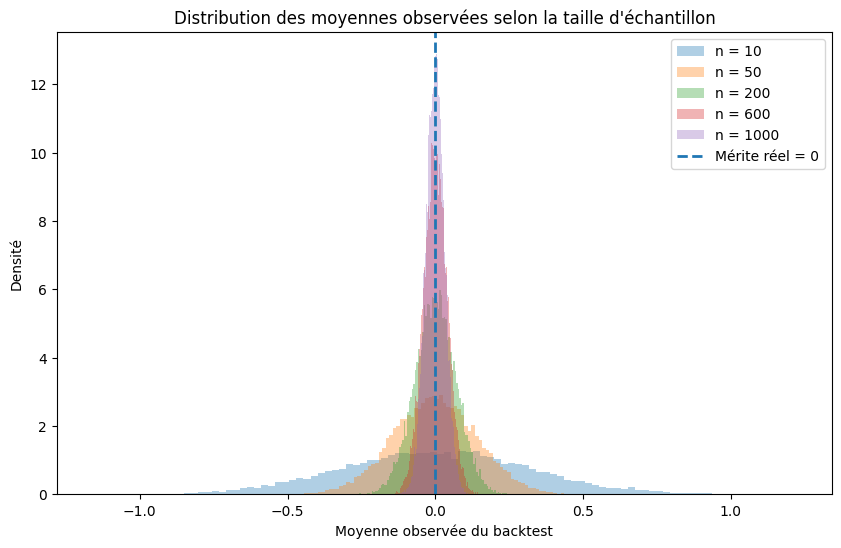

In [3]:
plt.figure(figsize=(10, 6))

for n in sample_sizes:
    plt.hist(
        sampling_distributions[n],
        bins=100,
        density=True,
        alpha=0.35,
        label=f"n = {n}"
    )

plt.axvline(0, linestyle="--", linewidth=2, label="Mérite réel = 0")
plt.title("Distribution des moyennes observées selon la taille d'échantillon")
plt.xlabel("Moyenne observée du backtest")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 5. Lecture du graphique

Le graphique montre que les petits échantillons produisent des distributions larges.

Cela signifie qu’une stratégie sans edge peut facilement afficher une moyenne très positive ou très négative.

À l’inverse, les grands échantillons produisent une distribution étroite autour de zéro.

> Quand $n$ augmente, la performance observée a de moins en moins d’espace pour mentir.

C’est exactement l’idée de la Figure 6.34 décrite par Aronson.


## 6. Simulation 2 — Data mining : sélectionner la meilleure règle par hasard

Maintenant, nous simulons le vrai problème EBTA.

Nous allons créer un univers de règles artificielles.

Chaque règle n’a aucun edge réel :

$$
\mu_i = 0
$$

Mais le data miner teste plusieurs règles, puis sélectionne celle qui a la meilleure moyenne historique.

Le biais de minage est alors :

$$
\text{Biais} = \mathbb{E}\left[\max(\bar{R}_1, \bar{R}_2, ..., \bar{R}_m)\right] - \mu
$$

Comme $\mu = 0$, le biais correspond simplement à la meilleure moyenne moyenne obtenue par hasard.


In [4]:
def simulate_data_mining_bias(
    n_observations,
    n_rules,
    n_experiments=10_000,
    mu=0.0,
    sigma=1.0
):
    """
    Simule le biais de minage.

    Pour chaque expérience :
    - on génère n_rules règles sans edge réel ;
    - chaque règle possède n_observations rendements ;
    - on calcule la moyenne de chaque règle ;
    - on retient la meilleure moyenne.

    Le biais est la moyenne des meilleurs scores sélectionnés.
    """
    returns = np.random.normal(
        loc=mu,
        scale=sigma,
        size=(n_experiments, n_rules, n_observations)
    )

    rule_means = returns.mean(axis=2)
    best_means = rule_means.max(axis=1)

    return best_means.mean(), best_means


observation_grid = [5, 10, 20, 50, 100, 200, 400, 600, 800, 1000]
rule_counts = [10, 100]

rows = []
best_mean_distributions = {}

for n_rules in rule_counts:
    for n_obs in observation_grid:
        bias, best_means = simulate_data_mining_bias(
            n_observations=n_obs,
            n_rules=n_rules
        )
        rows.append({
            "n_observations": n_obs,
            "n_rules": n_rules,
            "biais_moyen": bias
        })
        best_mean_distributions[(n_rules, n_obs)] = best_means

bias_df = pd.DataFrame(rows)
bias_df


,n_observations,n_rules,biais_moyen
0,5,10,0.686415
1,10,10,0.490143
2,20,10,0.347645
3,50,10,0.217021
4,100,10,0.153079
5,200,10,0.108018
6,400,10,0.077350
7,600,10,0.062859
8,800,10,0.054157
9,1000,10,0.048751


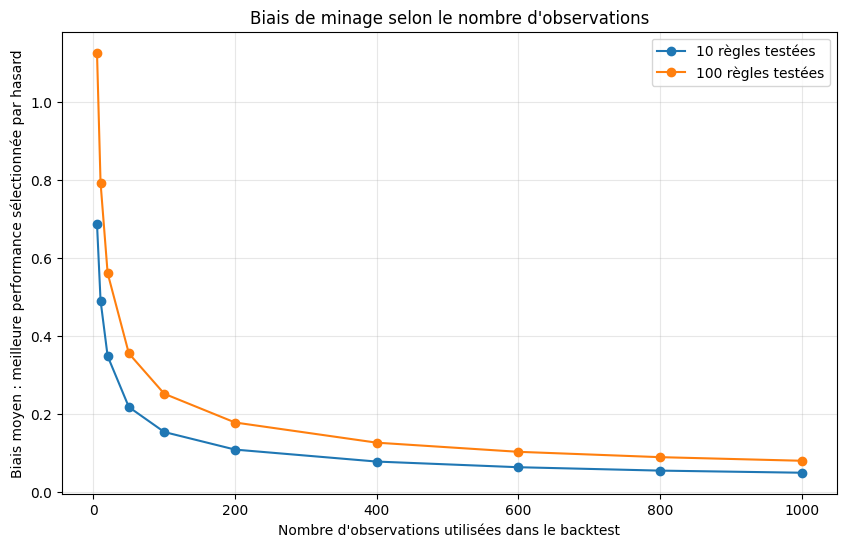

In [5]:
plt.figure(figsize=(10, 6))

for n_rules in rule_counts:
    subset = bias_df[bias_df["n_rules"] == n_rules]
    plt.plot(
        subset["n_observations"],
        subset["biais_moyen"],
        marker="o",
        label=f"{n_rules} règles testées"
    )

plt.title("Biais de minage selon le nombre d'observations")
plt.xlabel("Nombre d'observations utilisées dans le backtest")
plt.ylabel("Biais moyen : meilleure performance sélectionnée par hasard")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Lecture EBTA du résultat

On observe trois choses importantes :

1. Le biais est énorme quand le nombre d’observations est faible.

2. Tester 100 règles crée plus de biais que tester 10 règles.

3. Mais quand le nombre d’observations devient très grand, l’écart entre 10 règles et 100 règles diminue.

C’est exactement l’idée centrale d’Aronson :

> Un grand échantillon permet d’être plus ambitieux dans la recherche sans exploser le biais de minage.

Attention : cela ne veut pas dire qu’on peut optimiser sans limite.

Cela veut dire que la taille d’échantillon devient une protection statistique majeure.


## 8. Simulation 3 — Pourquoi 600 observations changent le jeu

Prenons deux cas :

| Cas | Description |
|---|---|
| $n = 20$ | historique court, très fragile |
| $n = 600$ | historique long, beaucoup plus robuste |

Nous allons observer la distribution de la meilleure règle sélectionnée par hasard parmi 100 règles.


In [6]:
short_history = best_mean_distributions[(100, 20)]
long_history = best_mean_distributions[(100, 600)]

comparison = pd.DataFrame({
    "cas": ["100 règles, n = 20", "100 règles, n = 600"],
    "moyenne_des_meilleurs_scores": [short_history.mean(), long_history.mean()],
    "quantile_95_des_meilleurs_scores": [
        np.quantile(short_history, 0.95),
        np.quantile(long_history, 0.95)
    ],
    "quantile_99_des_meilleurs_scores": [
        np.quantile(short_history, 0.99),
        np.quantile(long_history, 0.99)
    ]
})

comparison


,cas,moyenne_des_meilleurs_scores,quantile_95_des_meilleurs_scores,quantile_99_des_meilleurs_scores
0,"100 règles, n = 20",0.560361,0.733014,0.826044
1,"100 règles, n = 600",0.102343,0.134503,0.150685


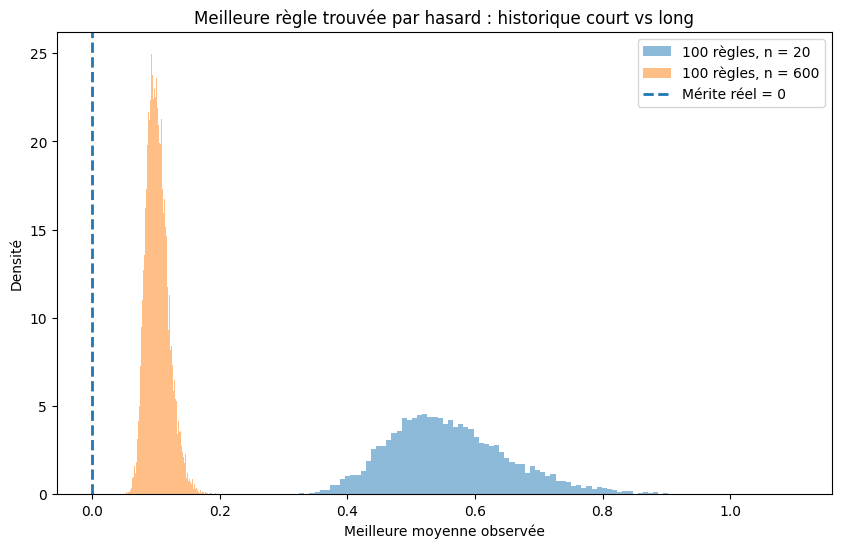

In [7]:
plt.figure(figsize=(10, 6))

plt.hist(short_history, bins=100, density=True, alpha=0.5, label="100 règles, n = 20")
plt.hist(long_history, bins=100, density=True, alpha=0.5, label="100 règles, n = 600")

plt.axvline(0, linestyle="--", linewidth=2, label="Mérite réel = 0")
plt.title("Meilleure règle trouvée par hasard : historique court vs long")
plt.xlabel("Meilleure moyenne observée")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 9. Interprétation pour un trader algorithmique

Avec un petit historique, le data miner peut facilement trouver une règle qui semble avoir un edge.

Mais cet edge est souvent une illusion statistique.

Avec un grand historique, la même recherche produit des performances beaucoup moins extrêmes.

La meilleure règle choisie par hasard reste positive, mais son avantage apparent est beaucoup plus faible.

> Le grand échantillon ne supprime pas le data mining bias, mais il le compresse fortement.


## 10. Application concrète au backtesting

Pour ton workflow EBTA, cette section donne une règle opérationnelle :

| Situation | Risque EBTA | Décision objective |
|---|---|---|
| Peu de trades ou peu de périodes | Biais massif | Ne pas valider |
| Beaucoup de variantes testées sur peu de données | Mirage très probable | Réduire la recherche ou augmenter l’historique |
| Long historique et beaucoup d’observations | Biais réduit | Validation plus crédible |
| Long historique + out-of-sample + correction MCP | Cadre robuste | Candidat sérieux |

Le point clé :

> Le nombre de trades compte autant que la beauté de l’equity curve.

Une equity curve magnifique sur 30 trades n’est pas une preuve.

C’est peut-être seulement une trajectoire chanceuse.


## 11. Mini-framework de décision EBTA

Voici une grille simple pour éviter de te faire piéger :

| Nombre d'observations | Lecture EBTA |
|---:|---|
| $n < 30$ | Trop fragile pour conclure |
| $30 \leq n < 100$ | Signal exploratoire seulement |
| $100 \leq n < 300$ | Analyse possible, mais prudente |
| $300 \leq n < 600$ | Base plus sérieuse |
| $n \geq 600$ | Zone de robustesse statistique supérieure |

Cette grille n’est pas une loi absolue.

Elle sert de garde-fou.

En pratique, il faut aussi considérer :

- la dépendance entre observations ;
- la stabilité temporelle du marché ;
- les frais ;
- le slippage ;
- le nombre de variantes testées ;
- la validation out-of-sample ;
- la correction du biais de data mining.


## 12. Eurêka final

> Le data mining adore les petits échantillons, parce que les petits échantillons donnent au hasard assez d’espace pour se déguiser en edge.

La taille d’échantillon est donc une arme défensive.

Elle ne crée pas l’alpha.

Elle empêche simplement le bruit de se faire passer pour de l’alpha.

Dans le langage du trader systématique :

> Plus tu testes sur peu de données, plus tu joues contre les statistiques.  
> Plus tu testes sur beaucoup de données, plus tu obliges ta stratégie à prouver son vrai mérite.


## 13. Checklist pratique

Avant de valider une stratégie, pose ces questions :

- Ai-je assez d’observations pour que la moyenne soit crédible ?
- Combien de règles ou paramètres ai-je testés avant de choisir celle-ci ?
- La performance vient-elle de quelques trades extrêmes ?
- Le Sharpe reste-t-il stable quand j’allonge l’historique ?
- Le résultat survit-il hors-échantillon ?
- Ai-je corrigé l’effet de sélection ?
- Ai-je séparé exploration, sélection et validation finale ?

> Une stratégie peut être rentable dans le backtest et pourtant ne rien valoir scientifiquement si l’échantillon est trop maigre.


## 14. Annexe — Source originale fournie


### **CH 6 : FACTOR 2 - NUMBER OF OBSERVATIONS USED TO COMPUTE THE PERFORMANCE STATISTIC**

Cette section analyse l'impact de la taille de l'échantillon (le nombre d'observations) sur l'ampleur du biais de minage de données. David Aronson considère ce facteur comme le plus crucial pour la validité des tests.

---

#### **Idées clés :**
*   **La primauté de l'échantillon :** De tous les facteurs influençant le biais, la taille de l'échantillon est probablement le plus important.
*   **Dilution de la chance :** Plus le nombre d'observations augmente, moins une coïncidence chanceuse (quelques mois très profitables par accident) peut gonfler artificiellement le rendement moyen.
*   **Loi des Grands Nombres :** Un échantillon large force la performance observée à converger vers le mérite réel de la règle.
*   **Seuil de sécurité :** Avec un échantillon suffisamment grand (ex: 600 mois), l'augmentation du nombre de règles testées n'augmente plus de manière significative le biais de minage.

---

#### **Référence :**
*Factor 2: Number of Observations Used to Compute the Performance Statistic* (Pages 299–301).

---

#### **Citation Directe :**
« In fact, of all the factors impacting the size of the bias, sample size may be the most important. The more observations used, the less opportunity there is for a few lucky observations (profitable months) to result in a high mean return. » (Page 299).

---

#### **Vision Macro :**
L'enjeu est la lutte contre le "bruit" temporel. David Aronson explique que le hasard est une force qui domine les petits nombres. En trading, un profit sur une courte période n'a quasiment aucune valeur scientifique. La "vérité" d'une règle ne peut émerger que si elle est soumise à une multitude d'épreuves sur une longue période. C'est l'application de la rigueur statistique pour transformer une intuition incertaine en une connaissance fondée sur des preuves.

---

#### **Vision Micro :**
Le mécanisme de réduction du biais par l'augmentation des observations repose sur la structure de la distribution d'échantillonnage :

1.  **Largeur de la distribution (Figure 6.34) :** Un petit échantillon produit une distribution "large". Cela signifie que la règle a statistiquement beaucoup d'espace pour s'écarter de la réalité par pure chance (gains ou pertes extrêmes). 
2.  **Resserrement de la distribution :** Un grand échantillon produit une distribution étroite. La performance observée est "prisonnière" du mérite réel, laissant très peu de place aux anomalies chanceuses.
3.  **L'expérience des ATR (Figure 6.35) :** Aronson a testé des univers de 10 et 100 règles en faisant varier la durée de l'historique de 1 à 1 000 mois.
    *   **Résultat :** Le biais chute de manière exponentielle. 
    *   **Constat majeur :** Lorsque l'échantillon atteint environ 600 mois, la différence de biais entre tester 10 règles et en tester 100 devient minuscule. Cela signifie qu'un historique long permet au data miner d'être beaucoup plus ambitieux dans ses recherches sans risquer de faux positifs.

---

#### **Résumé Simplifié :**
Plus tu as de données historiques, moins tu as de chances d'être trompé par un "coup de bol". Si tu testes une stratégie sur 10 mois, un seul bon mois peut te faire croire que tu es un génie. Si tu la testes sur 1 000 mois, la chance finit par s'annuler et seul le talent (le mérite réel) reste visible. 

---

#### **Actions Concrètes :**
*   **Priorité absolue à l'historique :** Avant de chercher à tester de nouvelles règles, cherchez à obtenir l'historique de données le plus long possible pour vos actifs.
*   **Scepticisme sur le court terme :** Soyez extrêmement méfiant face à des statistiques de performance (Sharpe, rendement) calculées sur un faible nombre de signaux ou d'intervalles de temps.
*   **Exploiter les grands échantillons :** Si vous disposez de données sur plusieurs décennies, vous pouvez vous permettre d'optimiser davantage de paramètres car le risque de biais est stabilisé par la masse de données.

---

#### **À retenir absolument :**
*   La taille d'échantillon est le **meilleur antidote** au biais de minage.
*   Peu de données = **Biais massif** (illusion de profit).
*   La Loi des Grands Nombres **travaille pour le trader objectif**.
*   À partir de **600 observations**, le biais devient très stable.
*   Ne jamais valider une stratégie sur un **historique "maigre"**.

J'ai terminé l'analyse du facteur 2 (nombre d'observations) selon le protocole EBTA.
```
